
scikit-learn Implementation Results:
Estimated weights: [  150.53178332 20116.92449578]
Estimated intercept: 50132.86296643852
Training MSE: 100396406.49
Test MSE: 81010790.98
R² score: 0.9908


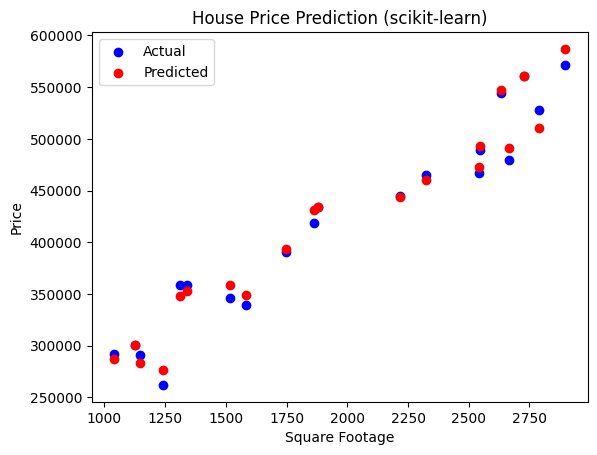

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generate same synthetic house price data
np.random.seed(42)
n_samples = 100

square_footage = np.random.uniform(1000, 3000, n_samples)
bedrooms = np.random.randint(2, 6, n_samples)
X = np.column_stack((square_footage, bedrooms))

true_weights = np.array([150, 20000])
true_intercept = 50000
y = X @ true_weights + true_intercept + np.random.normal(0, 10000, n_samples)

# Split data using sklearn's train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate MSE
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# Print results
print("\nscikit-learn Implementation Results:")
print(f"Estimated weights: {model.coef_}")
print(f"Estimated intercept: {model.intercept_}")
print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")
print(f"R² score: {model.score(X_test, y_test):.4f}")

# Visualize predictions vs actual (for square footage only)
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual')
plt.scatter(X_test[:, 0], y_pred_test, color='red', label='Predicted')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.title('House Price Prediction (scikit-learn)')
plt.legend()
plt.show()